# 03 – Encoding & Feature Selection (M3)
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Task:** Regression – predict **`Days for shipping (real)`** at order placement.
**Owner:** M3 – Primesh (Encoding & Frontend)

### The model's features (team decision)
| Feature | Type | Why it is known at order time |
|---|---|---|
| Shipping Mode | categorical | chosen when the order is placed |
| Market | categorical | destination region |
| Order Country | categorical (many values) | destination country |
| Category Name | categorical (many values) | what is ordered (Category Id carries the same information) |
| Order Item Quantity | numeric | how many items |
| Customer Segment | categorical | Consumer / Corporate / Home Office |
| order_weekday, order_month, order_hour, order_quarter, is_weekend | numeric | from the order timestamp (M2) |

### What this notebook does
1. Checks how many different values each categorical feature has (**cardinality**).
2. Shows that **target encoding leaks** if done wrongly – and is safe inside a pipeline.
3. Compares encoding strategies for the columns with many values, using grouped cross-validation.
4. Checks what each feature contributes, and compares the team list with simpler alternatives.
5. Saves the **encoding plan** that M4, the PE2 models and the backend all use.

### Input and output
| Input | Output |
|---|---|
| `data/processed/train_fe.csv`, `test_fe.csv` (from M2) | `results/m3_selection.json`, `results/m3_encoding_table.csv`, rows in `results/experiments.csv`, charts in `reports/figures/m3/` |

**Runtime:** Steps 4–5 train many models; allow several minutes on the full data.

## Step 0 – Setup
### 0.1 Imports, paths and the feature list
`CATEGORY_COL` uses **Category Name** if it exists; M1 drops Category Id because it is one-to-one with the name. If you prefer the Id, set
`CATEGORY_COL = "Category Id"` – it is then treated as a category, not a number.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "m3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Days for shipping (real)"
GROUP = "Order Id"
SEED = 42
LOW_CARD_MAX = 30          # up to 30 values -> one-hot; more -> high-cardinality strategy

CATEGORY_COL = "Category Name"
DATE_FEATURES = ["order_weekday", "order_month", "order_hour", "order_quarter", "is_weekend"]
BASE_FEATURES = ["Shipping Mode", "Market", "Order Country", CATEGORY_COL, "Order Item Quantity", "Customer Segment"]
FEATURES = BASE_FEATURES + DATE_FEATURES

def show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120)
    plt.show()

def log_experiment(row, path=RESULTS_DIR / "experiments.csv"):
    # Append one experiment to the shared team log, keeping columns aligned
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

### 0.2 The encoding plan and the preprocessor
- `make_plan()` decides how each feature is encoded:
  numeric → kept as a number; categorical with **≤ 30** values → **one-hot**; categorical with **> 30** values → the chosen **high-cardinality strategy**.
- `build_preprocessor()` turns a plan into a scikit-learn `ColumnTransformer` using only built-in encoders.

| Strategy for many-value columns | What it does |
|---|---|
| `onehot` | one 0/1 column per value (can be hundreds of columns) |
| `onehot_rare` | one-hot for values covering ≥ 1% of rows; all rare values share one "infrequent" column |
| `target` | each value → **the average shipping days for that value**, learned from training data (with smoothing) |
| `drop` | leave the column out (reference only) |

Unseen values never crash the model: one-hot ignores them, the infrequent bucket catches them, and target encoding gives them the overall average.

In [2]:
def make_plan(X, features, high_card="target"):
    numeric = [f for f in features if pd.api.types.is_numeric_dtype(X[f])]
    cats = [f for f in features if f not in numeric]
    low = [c for c in cats if X[c].nunique() <= LOW_CARD_MAX]
    high = [c for c in cats if c not in low]
    plan = {"numeric": numeric, "onehot": list(low), "onehot_rare": [], "target": [], "dropped": [], "high_card_strategy": high_card}
    if high_card == "onehot":
        plan["onehot"] += high
    elif high_card == "onehot_rare":
        plan["onehot_rare"] = high
    elif high_card == "target":
        plan["target"] = high
    else:
        plan["dropped"] = high
    return plan

def build_preprocessor(plan, numeric_steps=()):
    parts = []
    if plan["numeric"]:
        parts.append(("num", Pipeline([("impute", SimpleImputer(strategy="median")), *numeric_steps]), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="continuous", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

## Step 1 – Load the training data and the grouped CV folds
The folds are **grouped by Order Id** (no order in both training and validation) and **stratified** on the target, like M1's split.
They are created once and reused, so every comparison is fair.

In [3]:
train = pd.read_csv(PROCESSED_DIR / "train_fe.csv")
if CATEGORY_COL not in train.columns and "Category Id" in train.columns:
    CATEGORY_COL = "Category Id"
    BASE_FEATURES[3] = CATEGORY_COL
    FEATURES = BASE_FEATURES + DATE_FEATURES
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)      # an ID is a category, not a quantity

missing = [f for f in FEATURES if f not in train.columns]
assert not missing, f"Missing columns (run M1 and M2 first): {missing}"

X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))
print(f"Train: {len(X):,} rows, {groups.nunique():,} orders | {len(cv_splits)} grouped folds")
print("Features:", FEATURES)

Train: 138,098 rows, 50,318 orders | 5 grouped folds
Features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']


## Step 2 – Categorical features: cardinality, rare and unseen values
### 2.1 Cardinality table
How many values each categorical feature has, how dominant the top value is, and how many values are rare (< 30 rows).

In [4]:
CATS = [f for f in FEATURES if not pd.api.types.is_numeric_dtype(X[f])]
card = pd.DataFrame({
    "n_values": [X[c].nunique() for c in CATS],
    "top_value_%": [X[c].value_counts(normalize=True).iloc[0] * 100 for c in CATS],
    "rare_values_%": [(X[c].value_counts() < 30).mean() * 100 for c in CATS],
    "group": ["low -> one-hot" if X[c].nunique() <= LOW_CARD_MAX else "HIGH -> special" for c in CATS],
}, index=CATS).sort_values("n_values", ascending=False)
HIGH = card.index[card["group"].str.startswith("HIGH")].tolist()
card.round(1)

,n_values,top_value_%,rare_values_%,group
Order Country,161,13.7,26.7,HIGH -> special
Category Name,50,13.6,0.0,HIGH -> special
Market,5,28.6,0.0,low -> one-hot
Shipping Mode,4,59.8,0.0,low -> one-hot
Customer Segment,3,51.9,0.0,low -> one-hot


### 2.2 Long tail of the feature with the most values
Most values have very few rows. One-hot columns for them would be almost empty, and their plain averages would be unreliable.

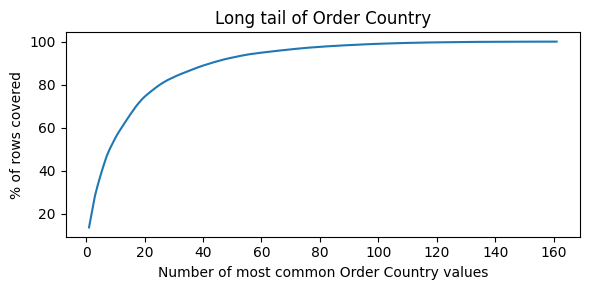

Top   5 values cover 38.2% of rows
Top  10 values cover 55.3% of rows
Top  20 values cover 74.4% of rows
Top  50 values cover 92.6% of rows


In [5]:
col = card.index[0]
coverage = X[col].value_counts(normalize=True).cumsum().reset_index(drop=True) * 100
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(1, len(coverage) + 1), coverage)
ax.set_xlabel(f"Number of most common {col} values"); ax.set_ylabel("% of rows covered"); ax.set_title(f"Long tail of {col}")
show(fig, "01_long_tail")
for n in [5, 10, 20, 50]:
    if n <= len(coverage):
        print(f"Top {n:>3} values cover {coverage.iloc[n - 1]:.1f}% of rows")

### 2.3 Unseen values in validation
How often a validation fold contains a value that its training part never saw – what will happen in production with new places.

In [6]:
unseen = {}
for c in CATS:
    shares = [(~X[c].iloc[va].isin(set(X[c].iloc[tr]))).mean() * 100 for tr, va in cv_splits]
    unseen[c] = np.mean(shares)
pd.Series(unseen, name="unseen_in_validation_%").round(3).to_frame()

,unseen_in_validation_%
Shipping Mode,0.000
Market,0.000
Order Country,0.033
Category Name,0.000
Customer Segment,0.000


## Step 3 – Target encoding and leakage
**Wrong way:** compute each value's average target on *all* training rows, then cross-validate – each validation row's own target
was used to make its feature. **Right way:** `TargetEncoder` inside a pipeline – it learns averages from the training folds only, and
uses internal cross-fitting plus smoothing towards the overall average. The gap between the two scores **is** the leakage.

In [7]:
SCORING = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
leak_col = card.index[0]

naive_feature = y.groupby(X[leak_col]).transform("mean").to_frame()          # WRONG: uses all rows
naive = cross_validate(LinearRegression(), naive_feature, y, cv=cv_splits, scoring=SCORING)

proper = cross_validate(Pipeline([("encode", TargetEncoder(target_type="continuous", random_state=SEED)),
                                  ("model", LinearRegression())]),
                        X[[leak_col]], y, cv=cv_splits, scoring=SCORING)                    # RIGHT: inside the pipeline

pd.DataFrame({
    "naive (leaky)": {"MAE": -naive["test_MAE"].mean(), "R2": naive["test_R2"].mean()},
    "inside pipeline": {"MAE": -proper["test_MAE"].mean(), "R2": proper["test_R2"].mean()},
}).round(4)

,naive (leaky),inside pipeline
MAE,1.4220,1.4277
R2,0.0042,-0.0024


## Step 4 – Compare encoding strategies for the many-value columns
### 4.1 Cross-validated comparison
Each strategy is tested with a **linear model (Ridge)** and a **tree model (HistGradientBoosting)** – they use encodings differently,
so a strategy that works for both is a safer choice. Scaling here is only for a fair Ridge comparison; M4 owns the final scaling.

In [8]:
STRATEGIES = ["drop", "onehot", "onehot_rare", "target"]
MODELS = {
    "Ridge": lambda: Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "HistGB": lambda: HistGradientBoostingRegressor(max_iter=200, random_state=SEED),
}

def evaluate(features, strategy, model_name):
    pipe = Pipeline([("prep", build_preprocessor(make_plan(X, features, strategy))), ("model", MODELS[model_name]())])
    s = cross_validate(pipe, X, y, cv=cv_splits, scoring=SCORING)
    return {"MAE": -s["test_MAE"].mean(), "RMSE": -s["test_RMSE"].mean(), "R2": s["test_R2"].mean(), "MAE_std": s["test_MAE"].std()}

rows = [{"strategy": st, "model": m, **evaluate(FEATURES, st, m)} for st in STRATEGIES for m in MODELS]
enc_results = pd.DataFrame(rows)
enc_results.round(4)

,strategy,model,MAE,RMSE,R2,MAE_std
0,drop,Ridge,0.9928,1.2711,0.3887,0.0079
1,drop,HistGB,0.9859,1.2789,0.3812,0.0089
2,onehot,Ridge,1.0027,1.2750,0.3850,0.0078
3,onehot,HistGB,0.9875,1.2798,0.3803,0.0081
4,onehot_rare,Ridge,0.9962,1.2715,0.3884,0.0077
5,onehot_rare,HistGB,0.9872,1.2790,0.3811,0.0083
6,target,Ridge,0.9960,1.2720,0.3878,0.0082
7,target,HistGB,0.9836,1.2760,0.3840,0.0062


### 4.2 Comparison chart

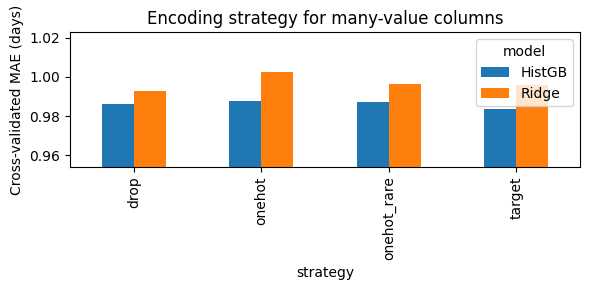

In [9]:
pivot = enc_results.pivot(index="strategy", columns="model", values="MAE").loc[STRATEGIES]
ax = pivot.plot.bar(figsize=(6, 3))
ax.set_ylabel("Cross-validated MAE (days)"); ax.set_title("Encoding strategy for many-value columns")
ax.set_ylim(pivot.min().min() * 0.97, pivot.max().max() * 1.02)
show(ax.figure, "02_encoding_comparison")

### 4.3 Choose the strategy
The team keeps Order Country and Category Name, so the final strategy is the best one **that keeps them** (`drop` is only a reference).
If `drop` scores about the same, those columns add little signal – an honest finding for the report.

In [10]:
keep_opts = enc_results[enc_results["strategy"] != "drop"].sort_values("MAE")
best = keep_opts.iloc[0]
BEST_STRATEGY = best["strategy"]
drop_best = enc_results[enc_results["strategy"] == "drop"]["MAE"].min()
print(f"Chosen: {BEST_STRATEGY} (best with {best['model']}, MAE {best['MAE']:.4f} ± {best['MAE_std']:.4f})")
print(f"Reference without the many-value columns: MAE {drop_best:.4f}")

Chosen: target (best with HistGB, MAE 0.9836 ± 0.0062)
Reference without the many-value columns: MAE 0.9859


## Step 5 – Check the feature list
### 5.1 Drop-column importance
On one held-out grouped fold: train with all features, then retrain **without each feature** (the 5 date features as one group).
Importance = how much the MAE rises when it is removed. Negative = the model did slightly better without it.

In [11]:
tr_idx, va_idx = cv_splits[0]
UNITS = {f: [f] for f in BASE_FEATURES}
UNITS["date features"] = DATE_FEATURES

def fold_mae(features):
    pipe = Pipeline([("prep", build_preprocessor(make_plan(X, features, BEST_STRATEGY))),
                     ("model", HistGradientBoostingRegressor(max_iter=200, random_state=SEED))])
    pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    return mean_absolute_error(y.iloc[va_idx], pipe.predict(X.iloc[va_idx]))

base_mae = fold_mae(FEATURES)
importance = pd.Series({u: fold_mae([f for f in FEATURES if f not in cols]) - base_mae for u, cols in UNITS.items()},
                       name="MAE_increase_when_removed").sort_values(ascending=False)
print(f"Validation MAE with all features: {base_mae:.4f}")
importance.round(4).to_frame()

Validation MAE with all features: 0.9860


,MAE_increase_when_removed
Shipping Mode,0.4442
date features,0.0049
Order Item Quantity,0.0008
Category Name,-0.0007
Market,-0.0028
Order Country,-0.0044
Customer Segment,-0.0133


### 5.2 Importance chart

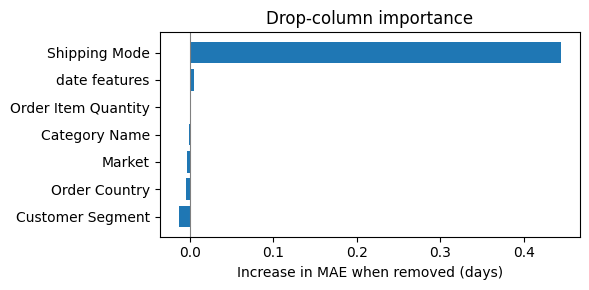

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(importance.index[::-1], importance.values[::-1])
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Increase in MAE when removed (days)"); ax.set_title("Drop-column importance")
show(fig, "03_drop_column_importance")

### 5.3 Team list vs simpler alternatives
Same folds, same encoding, both models. If the team list is within about one `MAE_std` of the best alternative, the extra features
cost nothing measurable – and they let the system react to destination, product, quantity and timing.

In [13]:
ALTERNATIVES = {
    "Shipping Mode only": ["Shipping Mode"],
    "team list without date features": BASE_FEATURES,
    "team list (FINAL)": FEATURES,
}
feat_rows = [{"feature_set": name, "n_features": len(fs), "model": m, **evaluate(fs, BEST_STRATEGY, m)}
             for name, fs in ALTERNATIVES.items() for m in MODELS]
feature_sets = pd.DataFrame(feat_rows)
feature_sets.round(4)

,feature_set,n_features,model,MAE,RMSE,R2,MAE_std
0,Shipping Mode only,1,Ridge,0.9867,1.2710,0.3888,0.0073
1,Shipping Mode only,1,HistGB,0.9870,1.2710,0.3888,0.0075
2,team list without date features,6,Ridge,0.9939,1.2722,0.3877,0.0079
3,team list without date features,6,HistGB,0.9945,1.2737,0.3863,0.0080
4,team list (FINAL),11,Ridge,0.9960,1.2720,0.3878,0.0082
5,team list (FINAL),11,HistGB,0.9836,1.2760,0.3840,0.0062


## Step 6 – The final encoding
### 6.1 Fit the final preprocessor
Fitted on the **training data only** (the target encoder needs `y`). The test set is only *transformed*, to prove it works on unseen data.

In [14]:
PLAN = make_plan(X, FEATURES, BEST_STRATEGY)
final_prep = build_preprocessor(PLAN)
Xt_tr = final_prep.fit_transform(X, y)

test = pd.read_csv(PROCESSED_DIR / "test_fe.csv")
if CATEGORY_COL == "Category Id":
    test[CATEGORY_COL] = test[CATEGORY_COL].astype(str)
Xt_te = final_prep.transform(test.drop(columns=[TARGET]))
out_names = final_prep.get_feature_names_out()
print("Train matrix:", Xt_tr.shape, "| Test matrix:", Xt_te.shape)
print("Missing values:", bool(np.isnan(Xt_tr).any() or np.isnan(Xt_te).any()))
print("Plan:", {k: v for k, v in PLAN.items() if v})

Train matrix: (138098, 20) | Test matrix: (34667, 20)
Missing values: False
Plan: {'numeric': ['Order Item Quantity', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend'], 'onehot': ['Shipping Mode', 'Market', 'Customer Segment'], 'target': ['Order Country', 'Category Name'], 'high_card_strategy': 'target'}


### 6.2 How each feature is encoded
Rule: **≤ 30 values → one-hot** (one 0/1 column per value); **> 30 values → the chosen strategy** – with target encoding, each
country or category becomes **one number: the average shipping days for it**, learned from the training data.

In [15]:
def n_cols(f):
    return sum(n.split("__", 1)[1] == f or n.split("__", 1)[1].startswith(f + "_") for n in out_names)

def how(f):
    for key, label in [("numeric", "number (as is)"), ("onehot", "one-hot"), ("onehot_rare", "one-hot + rare bucket"), ("target", "target encoding")]:
        if f in PLAN[key]:
            return label
    return "dropped"

encoding_table = pd.DataFrame({
    "different_values": [X[f].nunique() for f in FEATURES],
    "encoding": [how(f) for f in FEATURES],
    "model_columns": [n_cols(f) for f in FEATURES],
}, index=FEATURES)
encoding_table.to_csv(RESULTS_DIR / "m3_encoding_table.csv")
print(f"Total columns the model receives: {len(out_names)}")
encoding_table

Total columns the model receives: 20


,different_values,encoding,model_columns
Shipping Mode,4,one-hot,4
Market,5,one-hot,5
Order Country,161,target encoding,1
Category Name,50,target encoding,1
Order Item Quantity,5,number (as is),1
Customer Segment,3,one-hot,3
order_weekday,7,number (as is),1
order_month,12,number (as is),1
order_hour,24,number (as is),1
order_quarter,4,number (as is),1


### 6.3 What the target encoder learned (if target encoding is used)
For the busiest values: number of training rows, the plain average shipping days, and the number the model actually receives.
Values with few rows are pulled towards the overall average (smoothing); a value never seen in training gets the overall average.

In [16]:
if PLAN["target"]:
    te = final_prep.named_transformers_["target"]
    for col, cats, enc in zip(PLAN["target"], te.categories_, te.encodings_):
        learned = pd.Series(enc, index=cats)
        top = X[col].value_counts().head(5).index
        example = pd.DataFrame({
            "rows_in_train": X[col].value_counts()[top],
            "raw_average_days": y.groupby(X[col]).mean()[top].round(3),
            "encoded_value": learned[top].round(3),
        })
        print(f"\n{col}: {len(cats):,} values -> 1 column | unseen value -> {te.target_mean_:.3f}")
        print(example)
else:
    print(f"Strategy is '{BEST_STRATEGY}' - no target encoding used")


Order Country: 161 values -> 1 column | unseen value -> 3.500
                rows_in_train  raw_average_days  encoded_value
Order Country                                                 
Estados Unidos          18909             3.478          3.478
Francia                 10046             3.478          3.478
México                  10002             3.527          3.527
Alemania                 7251             3.518          3.518
Australia                6492             3.533          3.532

Category Name: 50 values -> 1 column | unseen value -> 3.500
                      rows_in_train  raw_average_days  encoded_value
Category Name                                                       
Cleats                        18806             3.501          3.501
Men's Footwear                17046             3.501          3.501
Women's Apparel               16026             3.482          3.482
Indoor/Outdoor Games          14764             3.505          3.505
Fishing             

## Step 7 – Save the decision and log the experiments
`m3_selection.json` holds the feature list and the exact encoding plan. M4, the PE2 models and the backend rebuild the same
preprocessor from it, so everyone trains on identical inputs.

In [17]:
decision = {
    "target": TARGET,
    "features": FEATURES,
    "category_column": CATEGORY_COL,
    "date_features": DATE_FEATURES,
    "low_card_max": LOW_CARD_MAX,
    "plan": PLAN,
    "cv": "StratifiedGroupKFold(5) grouped by Order Id",
    "cv_MAE_final_features": {r["model"]: round(float(r["MAE"]), 4)
                              for _, r in feature_sets[feature_sets["feature_set"] == "team list (FINAL)"].iterrows()},
    "n_model_columns": int(len(out_names)),
}
(RESULTS_DIR / "m3_selection.json").write_text(json.dumps(decision, indent=2, ensure_ascii=False), encoding="utf-8")

for _, r in enc_results.iterrows():
    log_experiment({"owner": "M3", "experiment": f"encoding_{r['strategy']}", "model": r["model"], "n_features": len(FEATURES),
                    "MAE": r["MAE"], "MAE_std": r["MAE_std"], "RMSE": r["RMSE"], "R2": r["R2"]})
for _, r in feature_sets.iterrows():
    log_experiment({"owner": "M3", "experiment": f"features_{r['feature_set']}", "model": r["model"], "n_features": r["n_features"],
                    "MAE": r["MAE"], "MAE_std": r["MAE_std"], "RMSE": r["RMSE"], "R2": r["R2"]})
print("Saved m3_selection.json, m3_encoding_table.csv; experiments.csv now has",
      len(pd.read_csv(RESULTS_DIR / "experiments.csv")), "rows")

Saved m3_selection.json, m3_encoding_table.csv; experiments.csv now has 93 rows


## Step 8 – Viva summary

In [18]:
fin = feature_sets[feature_sets["feature_set"] == "team list (FINAL)"].set_index("model")["MAE"]
print(f'''
FEATURES          {len(FEATURES)}: {", ".join(FEATURES)}
MANY-VALUE COLS   {", ".join(f"{c} ({X[c].nunique():,})" for c in HIGH) or "none"}
LEAKAGE DEMO      naive target encoding R2 {naive["test_R2"].mean():.3f} vs inside pipeline {proper["test_R2"].mean():.3f}
ENCODING          {BEST_STRATEGY} (CV MAE {best["MAE"]:.4f}); without those columns {drop_best:.4f}
MOST IMPORTANT    {", ".join(importance.index[:3])}
FINAL CV MAE      Ridge {fin["Ridge"]:.4f} | HistGB {fin["HistGB"]:.4f}
MODEL COLUMNS     {len(out_names)} after encoding
''')


FEATURES          11: Shipping Mode, Market, Order Country, Category Name, Order Item Quantity, Customer Segment, order_weekday, order_month, order_hour, order_quarter, is_weekend
MANY-VALUE COLS   Order Country (161), Category Name (50)
LEAKAGE DEMO      naive target encoding R2 0.004 vs inside pipeline -0.002
ENCODING          target (CV MAE 0.9836); without those columns 0.9859
MOST IMPORTANT    Shipping Mode, date features, Order Item Quantity
FINAL CV MAE      Ridge 0.9960 | HistGB 0.9836
MODEL COLUMNS     20 after encoding



**My contribution in one sentence:** I chose how every categorical feature is encoded, showed with cross-validation that target
encoding is safe only inside the pipeline, and checked what each of the team's features contributes.